In [2]:
import numpy as np
import xarray as xr    
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
# To interpolate NEMO data from Nico's mask files to the NEMO simulation grid 
from scipy.interpolate import griddata
import itertools
# To convert coordinates from lat, lon to polar stereo x,y 
from pyproj import Transformer
# KD Tree for nearest neighbours
from scipy.spatial import cKDTree
# To play a sound when at the end of the code you want to run 
import os
##os.system("printf '\a'")
import time
# To add a time delay when printing simple outputs (not necessary except for development)

#from tqdm.notebook import trange, tqdm
#import glob
#import seaborn as sns
#import datetime
#import time
#import os,sys
#import pandas as pd

#import tensorflow as tf
#from tensorflow import keras
#from contextlib import redirect_stdout

#from nn_functions.constants import *
#import nn_functions.diagnostic_functions as diag
#import nn_functions.data_formatting as dfmt
#import nn_functions.postprocessing_functions as pp
#from nn_functions.constants import *

filepath_data_ho = "/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/"
filepath_masks = filepath_data_ho + "masks_"
filepath_nico_on_nemo = filepath_data_ho + "nico_on_nemo_"
filepath_nn_input = filepath_data_ho + "nn_input_"
filepath_distances = filepath_data_ho + "grid_distances.nc" 

In [3]:
# For plotting things on the polar stereographic grid with lat and lon coordinates 
proj=ccrs.SouthPolarStereo(central_longitude=0.0)
trans=ccrs.PlateCarree()

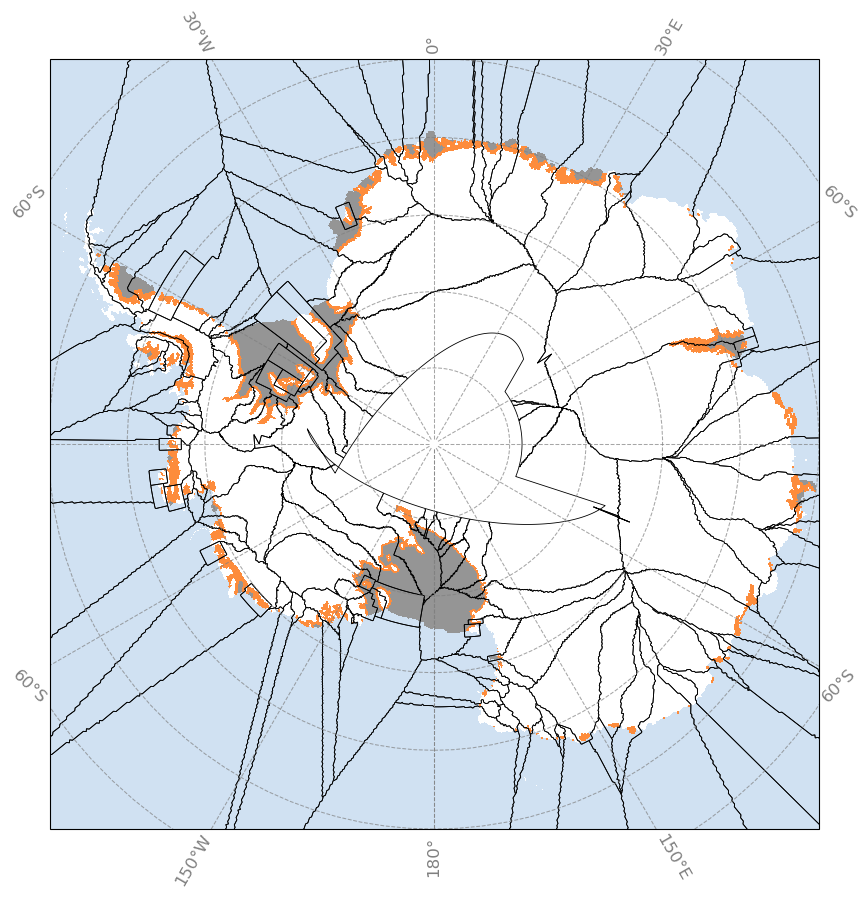

In [4]:
plot_all_boundaries = True
if plot_all_boundaries == True:
    # Load in the data specifically needed here
    ds0=xr.open_dataset('basin_raster_extrapolate_eANT025.nc')
    dsREF=xr.open_dataset('domain_cfg_eANT025.L121.nc')
    dsREDCAV=xr.open_dataset('domain_cfg_eANT025.L121_REDUCED_CAV.nc')
    dsREF = dsREF.squeeze('time_counter')
    dsREDCAV = dsREDCAV.squeeze('time_counter')
    Nbasin=ds0.basin.max()
    # Create masks for the ocean and closed cavities 
    ocean=xr.where(((dsREF.top_level>0.5)&(dsREF.top_level<1.5)),1,np.nan)
    isfREF=xr.where((dsREF.top_level>1.5),1,np.nan)
    closed=xr.where(((dsREF.top_level>1.5)&(dsREDCAV.top_level<0.5)),1,np.nan)
    lon2d=dsREF.glamt.values
    lat2d=dsREF.gphit.values
    # to avoid hexagons in cartopy:
    lon2d[lon2d>=180] = lon2d[lon2d>=180.] - 360.
    delta_lon=np.abs(np.diff(lon2d))
    for i, start in enumerate(np.argmax(delta_lon > 180, axis=1)):
      lon2d[i, start+1:] += 360
    # Plot the data 
    fig, axs = plt.subplots(nrows=1,ncols=1,
                            subplot_kw={'projection': proj},
                            figsize=(10.0,10.0))
    #axs = axs.ravel()
    # (lonmin, lonmax, latmin, latmax) :
    axs.set_extent( (-180, 180, -88, -65), trans )
    # Add and customize meridians/parallels
    gl0 = axs.gridlines(draw_labels=True, linewidth=0.75, color='gray', alpha=0.7, linestyle='--',
                           dms=True, x_inline=False, y_inline=False )
    gl0.xlocator = mticker.FixedLocator(np.arange(-180,210,30))
    gl0.ylocator = mticker.FixedLocator(np.arange(-90,-50,5))
    gl0.xformatter = LongitudeFormatter()
    gl0.yformatter = LatitudeFormatter()
    gl0.xlabel_style = {'size': 12, 'color': 'gray'}
    gl0.ylabel_style = {'size': 12, 'color': 'gray'}
    axs.pcolormesh(lon2d,lat2d,ocean, vmin=0.5, vmax=3.0, rasterized=True, cmap='Blues', transform=trans )
    axs.pcolormesh(lon2d,lat2d,isfREF, vmin=0.5, vmax=1.5, rasterized=True, cmap='Greys', transform=trans )
    axs.pcolormesh(lon2d,lat2d,closed, vmin=0., vmax=2.0, rasterized=True, cmap='YlOrRd', transform=trans )
    # Plot the basins as contour lines (probably a faster more efficient way to do this with a shapefile?
    ds0.basin[0:1,:]=0.
    for kbasin in np.arange(1,Nbasin+1,1):
      print(int(kbasin), 'out of', int(Nbasin.data), end = '\r')
      tmp = ds0.basin.values
      tmp = np.where(np.abs(tmp-kbasin)<0.1,1,0)
      axs.contour( lon2d, lat2d, tmp, [0.5], colors='k', linewidths=0.6, transform=trans )
    # Save the figure
    fig.savefig('map_masks.jpg')
    fig.savefig('map_masks.pdf')

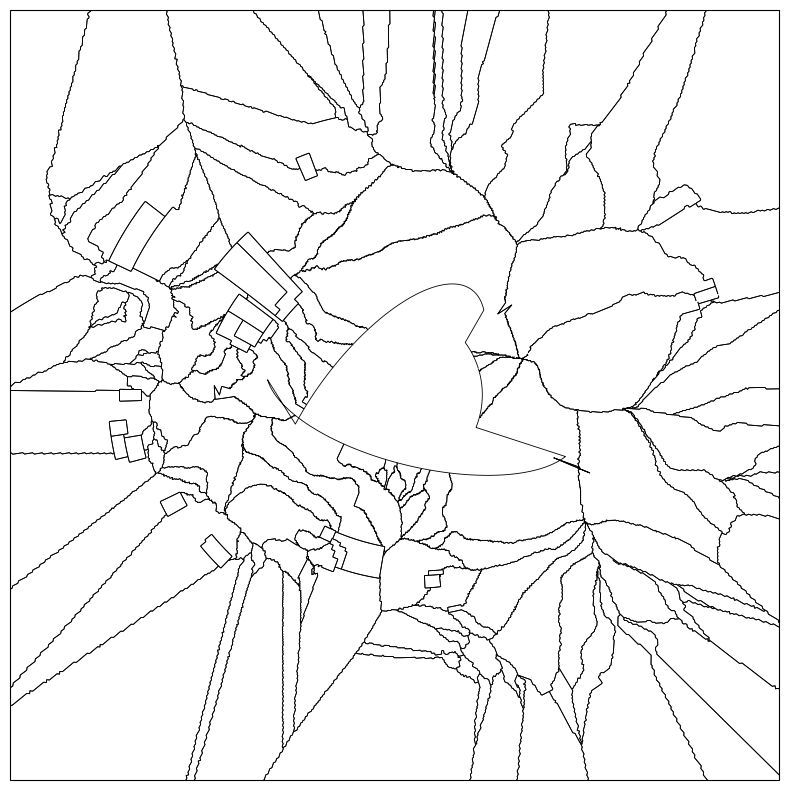

In [74]:
# Load in the data specifically needed here
ds0=xr.open_dataset('basin_raster_extrapolate_eANT025.nc')
Nbasin=ds0.basin.max()
lon2d=dsREF.glamt.values
lat2d=dsREF.gphit.values
# to avoid hexagons in cartopy:
lon2d[lon2d>=180] = lon2d[lon2d>=180.] - 360.
delta_lon=np.abs(np.diff(lon2d))
for i, start in enumerate(np.argmax(delta_lon > 180, axis=1)):
  lon2d[i, start+1:] += 360
# Plot the data 
fig, axs = plt.subplots(nrows=1,ncols=1,
                        subplot_kw={'projection': proj},
                        figsize=(10.0,10.0))
#axs = axs.ravel()
# (lonmin, lonmax, latmin, latmax) :
axs.set_extent( (-180, 180, -88, -65), trans )
# Plot the basins as contour lines (probably a faster more efficient way to do this with a shapefile?
ds0.basin[0:1,:]=0.
for kbasin in np.arange(1,Nbasin+1,1):
  print(int(kbasin), 'out of', int(Nbasin.data), end = '\r')
  tmp = ds0.basin.values
  tmp = np.where(np.abs(tmp-kbasin)<0.1,1,0)
  axs.contour( lon2d, lat2d, tmp, [0.5], colors='k', linewidths=0.6, transform=trans )

In [20]:
base = np.zeros((439, 1440))
for kbasin in np.arange(1,Nbasin+1,1):
    print(int(kbasin), 'out of', int(Nbasin.data), end = '\r')
    tmp = ds0.basin.values
    tmp = np.where(np.abs(tmp-kbasin)<0.1,1,0)
    base = base + (tmp*kbasin)

In [54]:
 # Load in the data specifically needed here
ds0=xr.open_dataset('basin_raster_extrapolate_eANT025.nc')
dsREF=xr.open_dataset('domain_cfg_eANT025.L121.nc')
dsREDCAV=xr.open_dataset('domain_cfg_eANT025.L121_REDUCED_CAV.nc')
dsREF = dsREF.squeeze('time_counter')
dsREDCAV = dsREDCAV.squeeze('time_counter')
Nbasin=ds0.basin.max()
# Create masks for the ocean and closed cavities 
ocean=xr.where(((dsREF.top_level>0.5)&(dsREF.top_level<1.5)),1,np.nan)
isfREF=xr.where((dsREF.top_level>1.5),1,np.nan)
closed=xr.where(((dsREF.top_level>1.5)&(dsREDCAV.top_level<0.5)),1,np.nan)
lon2d=dsREF.glamt.values
lat2d=dsREF.gphit.values
# to avoid hexagons in cartopy:
lon2d[lon2d>=180] = lon2d[lon2d>=180.] - 360.
delta_lon=np.abs(np.diff(lon2d))
for i, start in enumerate(np.argmax(delta_lon > 180, axis=1)):
  lon2d[i, start+1:] += 360

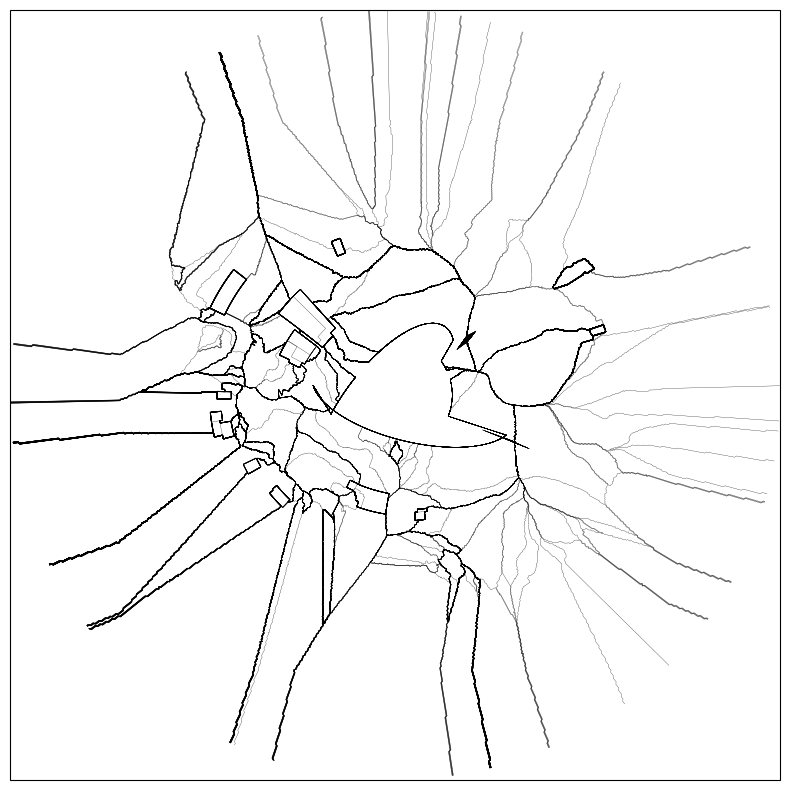

In [31]:
#plt.pcolor(base)
#plt.colorbar()
fig, ax = plt.subplots(1,1, figsize = (10,10), subplot_kw={'projection': proj})
plt.contour( lon2d, lat2d, base, colors='k', linewidths=0.2, transform=trans, levels = np.arange(1,Nbasin+1,1) + 0.5)

In [4]:
# Plot the bathymetry and ice draft for the whole domain 
plot_bathy_draft = False
if plot_bathy_draft == True:
    # Load in the required data 
    dsREF=xr.open_dataset('domain_cfg_eANT025.L121.nc')
    # Plot the figure 
    fig, axs = plt.subplots(nrows=1,ncols=2,
                            subplot_kw={'projection': proj},
                            figsize=(10.0,5.0))
    im = [[],[]]
    titles = ['Bathymetry','Ice Shelf Draft']
    im[0] = axs[0].scatter(dsREF.nav_lon.data, dsREF.nav_lat.data, c = dsREF.bathy_metry, transform = trans, cmap = 'Blues')
    im[1] = axs[1].scatter(dsREF.nav_lon.data, dsREF.nav_lat.data, c = dsREF.isf_draft, transform = trans, cmap = 'Blues')
    for i in range(2):
        plt.colorbar(im[i], ax = axs[i], shrink = 0.5)
        axs[i].axis('off');
        axs[i].set_title(titles[i])
    bounds = [-2e6,2.5e6,-2.2e6,2.2e6]
    axs[1].set_xlim(bounds[0], bounds[1]);
    axs[1].set_ylim(bounds[2], bounds[3]);
    dsREF.close()

In [5]:
# Create masks for the NEMO grid for this set of simulations 

In [6]:
# Set filepath to the specified year 
filepath_gridT_varofint = filepath_raw_NEMO + 'eORCA025.L121-OPM018_y' + str(year_of_interest) + '.1y_gridT_varofint.nc'
# Load in the simulation files 
gridT_varofint = xr.open_dataset(filepath_gridT_varofint)

NameError: name 'filepath_raw_NEMO' is not defined

In [9]:
def make_masks_func(nemo_run, filepath_raw_NEMO, year_of_interest, filepath_masks, filepath_dsREDCAV, filepath_basin_nos, \
                    skip_interpolation = True, need_to_calculate_distances = False):
    """ This function will take one run of the NEMO simulation and create masks for """
    """ where there are open and closed cavities, and ocean and grounded ice.       """
    """ It also calculates the basin numbers, and can do the grid distances         """
    """ It requires one run for NEMO 1 degree for comparison                        """
    # Set filepath to the specified year 
    filepath_gridT_varofint = filepath_raw_NEMO + 'eORCA025.L121-OPM018_y' + str(year_of_interest) + '.1y_gridT_varofint.nc'
    # Load in the simulation files 
    gridT_varofint = xr.open_dataset(filepath_gridT_varofint)
    # Remove the time counter axis 
    gridT_varofint = gridT_varofint.squeeze('time_counter').sel(bnds=1).drop('time_counter_bnds').drop('time_counter')
    # Crop out most of the world and just save Antarctica 
    # Set coordinates
    min_lat = -90
    max_lat = -51
    # Create mask for these
    mask_lat = (gridT_varofint.nav_lat >= min_lat) & (gridT_varofint.nav_lat <= max_lat)
    # Select only region of interest
    gridT2 = gridT_varofint.where(mask_lat, drop=True)
    # Remove the time_counter_axis 
    #gridT2 = gridT.squeeze('time_counter').sel(bnds=1).drop('time_counter_bnds').drop('time_counter')
    gridT_varofint.close()
    if skip_interpolation == False:
        # Open Nico's data to do the interpolation
        ds0=xr.open_dataset(filepath_basin_nos)
        dsREDCAV=xr.open_dataset(filepath_dsREDCAV)
        dsREDCAV = dsREDCAV.squeeze('time_counter')
        # Interpolate Nico's data onto the grid 
        x_flat = np.ndarray.ravel(dsREDCAV.nav_lon.data)
        y_flat = np.ndarray.ravel(dsREDCAV.nav_lat.data)
        z_flat = np.ndarray.ravel(ds0.basin.data)
        dsREDCAV_flat = np.ndarray.ravel(dsREDCAV.top_level.data)
        ds0.close()
        dsREDCAV.close()
        basins_NEMO = griddata((x_flat,y_flat), z_flat, (gridT2.nav_lon, gridT2.nav_lat), method = 'nearest')
        dsREDCAV_NEMO = griddata((x_flat,y_flat), dsREDCAV_flat, (gridT2.nav_lon, gridT2.nav_lat), method = 'nearest')
        # Save these arrays to an xarray dataset to load in later
        ds = xr.Dataset(
        data_vars=dict(
            dsREDCAV_NEMO=(["y", "x"], dsREDCAV_NEMO),
            basins_NEMO=(["y", "x"], basins_NEMO),    ),
        coords=dict(
            lon=(("y", "x"), gridT2.nav_lon.data),
            lat=(("y", "x"), gridT2.nav_lat.data),    ),
        attrs=dict(description="Basin numbers and limit of cavity resolutions", 
                   simulation_run = nemo_run),
        )
        # Save these pre-interpolated grids
        ds.to_netcdf(filepath_nico_on_nemo +nemo_run +'.nc')
    else:
        # Load the pre-interpolated grids from file
        ds_load = xr.open_dataset(filepath_nico_on_nemo+nemo_run + '.nc')
        dsREDCAV_NEMO = ds_load.dsREDCAV_NEMO.data
        basins_NEMO = ds_load.basins_NEMO.data
        ds_load.close()
    # Calculate the depth of the ice-ocean interface 
    mask_temp_values = xr.where(gridT2.votemper > -200, 1,0)
    mask_diff_temp = (mask_temp_values - mask_temp_values.shift(deptht=1))
    positive = xr.where(mask_diff_temp == 1, 1, np.nan)
    positive_10 = xr.where(mask_diff_temp == 1, 1, 0)
    negative = xr.where(mask_diff_temp == -1, 1, np.nan)
    negative_10 = xr.where(mask_diff_temp == -1, 1, 0)
    # Create the masks for the regions which will be of interest later 
    # All the cavities
    all_cavities = positive_10.sum(dim = 'deptht')
    all_cavities_nan = xr.where(all_cavities == 1, 1, np.nan)
    # The ocean and all the cavities 
    ocean_all_cavities = negative_10.sum(dim = 'deptht')
    ocean_all_cavities_nan = xr.where(ocean_all_cavities == 1, 1, np.nan)
    # Grounded ice (not the ocean or a cavity)
    grounded_ice = 1 - ocean_all_cavities 
    grounded_ice_nan = xr.where(grounded_ice == 1, 1, np.nan)
    # Only the ocean 
    ocean_only = ocean_all_cavities - all_cavities
    ocean_only_nan = xr.where(ocean_only == 1, 1, np.nan)
    # Only cavities which are open in NEMO 1 degree 
    open_cavities_mask = dsREDCAV_NEMO > 1
    open_cavities = np.ones(open_cavities_mask.shape)
    open_cavities_nan = np.ones(open_cavities_mask.shape)
    open_cavities[open_cavities_mask == False] = 0
    open_cavities_nan[open_cavities_mask == False] = np.nan
    # Cavities which are open in NEMO 0.25 degree but not NEMO 1 degree 
    closed_cavities = all_cavities - open_cavities
    closed_cavities_nan = xr.where(closed_cavities == 1, 1, np.nan)
    # The ocean and oepn cavities (to calculate the local ice shelf front) 
    ocean_open_cavities = ocean_only + open_cavities
    ocean_open_cavities_nan = xr.where(ocean_open_cavities == 1, 1, np.nan)
    # Create an xr Dataset to save these variables to 
    ds = xr.Dataset(
        data_vars=dict(
            all_cavities=(["y", "x"], all_cavities.data),
            all_cavities_nan=(["y", "x"], all_cavities_nan.data),
            ocean_all_cavities=(["y", "x"], ocean_all_cavities.data),
            ocean_all_cavities_nan=(["y", "x"], ocean_all_cavities_nan.data),
            ocean_only=(["y", "x"], ocean_only.data),
            ocean_only_nan=(["y", "x"], ocean_only_nan.data),
            open_cavities=(["y", "x"], open_cavities.data),
            open_cavities_nan=(["y", "x"], open_cavities_nan.data),
            closed_cavities=(["y", "x"], closed_cavities.data),
            closed_cavities_nan=(["y", "x"], closed_cavities_nan.data),
            ocean_open_cavities=(["y", "x"], ocean_open_cavities.data),
            ocean_open_cavities_nan=(["y", "x"], ocean_open_cavities_nan.data),
            grounded_ice=(["y", "x"], grounded_ice.data),
            grounded_ice_nan=(["y", "x"], grounded_ice_nan.data),    ),
        coords=dict(
            lon=(("y", "x"), gridT2.nav_lon.data),
            lat=(("y", "x"), gridT2.nav_lat.data),    ),
        attrs=dict(description="Masks for grounded ice, floating ice and open ocean", 
                   simulation_run = nemo_run),
    )
    # Save the variable to netcdf
    ds.to_netcdf(filepath_masks + nemo_run + '.nc')
    print('Masks saved to netcdf')
    if need_to_calculate_distances == True:
        # In order to calculate the slopes we need the distance between points, 
        # and because the points are on the NEMO lat-lon grid we need to convert them to polar stereo the calculate the distances 
        # Create a pyproj transformer to transform onto polar stereo
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        lat, lon = gridT2.nav_lat.data, gridT2.nav_lon.data
        grid_x, grid_y = transformer.transform(lat, lon)
        # Use the np.roll function to move the data slightly 
        shifted_x_p0 = (grid_x - np.roll(grid_x, shift = 1, axis = 0))
        shifted_x_m0 = (grid_x - np.roll(grid_x, shift = -1, axis = 0))
        shifted_x_p1 = (grid_x - np.roll(grid_x, shift = 1, axis = 1))
        shifted_x_m1 = (grid_x - np.roll(grid_x, shift = -1, axis = 1))
        shifted_y_p0 = (grid_y - np.roll(grid_y, shift = 1, axis = 0))
        shifted_y_m0 = (grid_y - np.roll(grid_y, shift = -1, axis = 0))
        shifted_y_p1 = (grid_y - np.roll(grid_y, shift = 1, axis = 1))
        shifted_y_m1 = (grid_y - np.roll(grid_y, shift = -1, axis = 1))
        # Because you need to calculate the hypotenuse distance you need x and y for both directions of shift 
        shifted_p_lon = np.sqrt(shifted_x_p0**2 + shifted_y_p0**2) # lon
        shifted_m_lon = np.sqrt(shifted_x_m0**2 + shifted_y_m0**2) # lon 
        shifted_p_lat = np.sqrt(shifted_x_p1**2 + shifted_y_p1**2) # lat
        shifted_m_lat = np.sqrt(shifted_x_m1**2 + shifted_y_m1**2) # lat
        # And then save these to file 
        ds = xr.Dataset(
            data_vars=dict(
                dist_p_lon=(["y", "x"], shifted_p_lon),
                dist_m_lon=(["y", "x"], shifted_m_lon),
                dist_p_lat=(["y", "x"], shifted_p_lat),
                dist_m_lat=(["y", "x"], shifted_m_lat),    ),
            coords=dict(
                lon=(("y", "x"), gridT2.nav_lon.data),
                lat=(("y", "x"), gridT2.nav_lat.data),    ),
            attrs=dict(description="Distances", 
                       simulation_run = nemo_run),
        )
        ds.to_netcdf(filepath_distances)
        print('Distances saved to netcdf')

In [10]:
nemo_run = 'OPM018'
#yy_start = 1980
#yy_end = 2008
filepath_raw_NEMO = '/bettik/burgardc/DATA/BASAL_MELT_PARAM/raw/NEMO_eORCA025.L121-' + nemo_run + '/'
year_of_interest = 1990
skip_interpolation = True
filepath_dsREDCAV = 'domain_cfg_eANT025.L121_REDUCED_CAV.nc'
filepath_basin_nos = 'basin_raster_extrapolate_eANT025.nc'
need_to_calculate_distances = True

In [11]:
%%time
need_to_make_masks = False
if need_to_make_masks == True:
   make_masks_func(nemo_run, filepath_raw_NEMO, year_of_interest, filepath_masks, filepath_dsREDCAV, filepath_basin_nos, \
                    skip_interpolation, need_to_calculate_distances)

CPU times: user 8 μs, sys: 2 μs, total: 10 μs
Wall time: 17.2 μs


In [12]:
# If you want to plot the masks produced 
plot_masks = False
if plot_masks == True:
    # Load in the data
    ds_verify = xr.open_dataset(filepath_masks+nemo_run + '.nc')
    # And plot the masks
    fig, ax = plt.subplots(2,2, figsize = (12,8))
    im = [[[],[]],[[],[]]]
    titles = [['Open ocean', 'Open cavities'],['Closed cavities','Grounded ice']]
    im[0][0] = ax[0,0].pcolor(ds_verify.ocean_only, cmap = 'Greys')
    im[1][0] = ax[1,0].pcolor(ds_verify.closed_cavities, cmap = 'Greys')
    im[0][1] = ax[0,1].pcolor(ds_verify.open_cavities, cmap = 'Greys')
    im[1][1] = ax[1,1].pcolor(ds_verify.grounded_ice, cmap = 'Greys')
    for i,j in itertools.product(range(2), range(2)):
        ax[i,j].set_title(titles[i][j])
    ds_verify.close()

In [13]:
# Calculate areas 
ds_distances = xr.open_dataset(filepath_distances)
ds_verify = xr.open_dataset(filepath_masks+nemo_run + '.nc')

In [14]:
filepath_distances

'/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/grid_distances.nc'

In [7]:
dist_lat = (ds_distances.dist_p_lat +  ds_distances.dist_m_lat) /2
dist_lon = (ds_distances.dist_p_lon +  ds_distances.dist_m_lon) /2
plt.pcolor(dist_lat*dist_lon * ds_verify.all_cavities_nan)
plt.colorbar()
plt.clim(0, 1e8)

NameError: name 'ds_distances' is not defined

In [10]:
# If you want to plot the distances 
plot_dists = False
if plot_dists == True:
    # Load in the data 
    ds_distances = xr.open_dataset(filepath_distances)
    ds_verify = xr.open_dataset(filepath_masks+nemo_run + '.nc')
    # And plot the masks
    fig, ax = plt.subplots(2,2, figsize = (12,8))
    im = [[[],[]],[[],[]]]
    titles = [['Difference (+lat direction)', 'Difference (-lat direction)'],\
              ['Difference (+lon direction)', 'Difference (-lon direction)']]
    im[0][0] = ax[0,0].pcolor(ds_distances.dist_p_lat * ds_verify.all_cavities_nan, cmap = 'viridis')
    im[1][0] = ax[1,0].pcolor(ds_distances.dist_m_lat * ds_verify.all_cavities_nan, cmap = 'viridis')
    im[0][1] = ax[0,1].pcolor(ds_distances.dist_p_lon * ds_verify.all_cavities_nan, cmap = 'viridis')
    im[1][1] = ax[1,1].pcolor(ds_distances.dist_m_lon * ds_verify.all_cavities_nan, cmap = 'viridis')
    for i,j in itertools.product(range(2), range(2)):
        ax[i,j].set_title(titles[i][j])
    ds_distances.close()

In [11]:
# Extract the useful parameters for the NN (melt, T and S, bathy etc) 

In [12]:
def extract_useful_variables(nemo_run, year_of_interest, filepath_raw_NEMO, filepath_masks, verbose = 0):
    filepath_gridT_varofint = filepath_raw_NEMO + 'eORCA025.L121-OPM018_y' + str(year_of_interest) + '.1y_gridT_varofint.nc'
    filepath_flxT_varofint = filepath_raw_NEMO + 'eORCA025.L121-OPM018_y' + str(year_of_interest) + '.1y_flxT_varofint.nc'
    # Load in the simulation files 
    gridT_varofint = xr.open_dataset(filepath_gridT_varofint)
    # votemper = sea_water_potential_temperature
    # vosaline = sea_water_practical_salinity
    # sosbt = sea bottom temperature
    # sosbs = sea bottom salinity
    # sosst = sea surface temperature
    # sosss = sea surface salinity 
    flxT_varofint = xr.open_dataset(filepath_flxT_varofint)
    # sowflisf_cav ice shelf melt rate in kg/m2/s
    # Cut out variables which are not needed 
    flxT_varofint = flxT_varofint.squeeze('time_counter').sel(bnds=1).drop('time_counter_bnds').drop('time_counter')
    gridT_varofint = gridT_varofint.squeeze('time_counter').sel(bnds=1).drop('time_counter_bnds').drop('time_counter')
    # Crop out most of the world and just save Antarctica 
    # Set coordinates
    min_lat = -90
    max_lat = -51
    # Create mask for these
    mask_lat = (gridT_varofint.nav_lat >= min_lat) & (gridT_varofint.nav_lat <= max_lat)
    mask_lat = (flxT_varofint.nav_lat >= min_lat) & (flxT_varofint.nav_lat <= max_lat)
    # Select only region of interest
    gridT2 = gridT_varofint.where(mask_lat, drop=True)
    flxT2 = flxT_varofint.where(mask_lat, drop=True)
    if verbose == 2:
        print('Data loaded and cropped')
    # The melt rate comes directly from flxT2.sowflisf_cav (ice shelf melt rate in kg/m2/s)
    # Calculate the distance to the grounding line, distance to the local ice front, and distance to the far away ice front
    # Load in masks 
    masks = xr.open_dataset(filepath_masks + nemo_run + '.nc')
    ocean_open_cavities = masks.ocean_open_cavities.data
    grounded_ice = masks.grounded_ice.data
    ocean_only = masks.ocean_only.data
    closed_cavities = masks.closed_cavities.data
    masks.close()
    # Create pyproj transformer to transform from lat lon to polar sterographic 
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    # Create a list of all the grounded ice points
    GL_lat, GL_lon = gridT2.nav_lat.data[grounded_ice == 1], gridT2.nav_lon.data[grounded_ice == 1]
    GL_x, GL_y = transformer.transform(GL_lat, GL_lon)
    points_GL = np.array(list(zip(GL_x, GL_y)))
    # Create a list of all the points in closed ice shelves 
    CC_lat, CC_lon = gridT2.nav_lat.data[closed_cavities == 1], gridT2.nav_lon.data[closed_cavities == 1]
    CC_x, CC_y = transformer.transform(CC_lat, CC_lon)
    points_CC = np.array(list(zip(CC_x, CC_y)))
    # Create the cKD Tree for the grounding line 
    tree = cKDTree(points_GL)
    # Query the cKD Tree for the closed cavity points 
    dist, index = tree.query(points_CC, k = 1)
    distances_GL = np.ones(gridT2.nav_lat.data.shape)*np.nan
    distances_GL[closed_cavities == 1] = dist
    # Create a list of all the open ocean points 
    OO_lat, OO_lon = gridT2.nav_lat.data[ocean_only == 1], gridT2.nav_lon.data[ocean_only == 1]
    OO_x, OO_y = transformer.transform(OO_lat, OO_lon)
    points_OO = np.array(list(zip(OO_x, OO_y)))
    # Create the cKD Tree for the open ocean
    tree = cKDTree(points_OO)
    # Query the cKD Tree for the closed cavity points 
    dist, index = tree.query(points_CC, k = 1)
    distances_OO = np.ones(gridT2.nav_lat.data.shape)*np.nan
    distances_OO[closed_cavities == 1] = dist
    if verbose == 2:
        print('Some distances calculated')
    # To calculate the distance to the nearest local ocean point (this is needed for the T_S profiles too)
    # There are complications because the nearest ocean point is not necessarily the nearest connected ocean point 
    # Load in the basins mask
    nico_on_nemo = xr.open_dataset(filepath_nico_on_nemo + nemo_run + '.nc')
    basins_NEMO = nico_on_nemo.basins_NEMO.data
    nico_on_nemo.close()
    # Some ice shelves which should potentially be joined together into one bigger ice shelf
    join_ice_shelves = True
    if join_ice_shelves == True:
        # Dotson and Crosson?
        #basins_NEMO[basins_NEMO == 101] = 129
        # Abbot Ice Shelf
        basins_NEMO[basins_NEMO == 109] = 143
        # George VI
        basins_NEMO[basins_NEMO == 112] = 125
        # Lambert 
        basins_NEMO[basins_NEMO == 20] = 103
    # Calculate the basin numbers of any basin which contains closed cavities 
    basin_nos_temp = np.unique(basins_NEMO)
    count = np.zeros(len(basin_nos_temp))
    for i in range(len(basin_nos_temp)):
        count[i] = np.sum((basins_NEMO*masks.closed_cavities_nan) == basin_nos_temp[i])
    mask_keep_nos = count != 0
    basin_nos = basin_nos_temp[mask_keep_nos]
    # Create a list of all the open ocean and open cavity points 
    OC_lat, OC_lon = gridT2.nav_lat.data[ocean_open_cavities == 1], gridT2.nav_lon.data[ocean_open_cavities == 1]
    OC_x, OC_y = transformer.transform(OC_lat, OC_lon)
    points_OC = np.array(list(zip(OC_x, OC_y)))
    # Create a cKD Tree for the ocean points 
    tree = cKDTree(points_OC)
    # Calculate the depth of the ice-ocean interface 
    mask_temp_values = xr.where(gridT2.votemper > -200, 1,0)
    mask_diff_temp = (mask_temp_values - mask_temp_values.shift(deptht=1))
    positive = xr.where(mask_diff_temp == 1, 1, np.nan)
    negative = xr.where(mask_diff_temp == -1, 1, np.nan)
    # Create an empty array for the local distances 
    distances_OC = np.ones(gridT2.nav_lat.data.shape)*np.nan
    # Create empty arrays for the propagated temperature and salinity (on NEMO grid)
    T_prop = np.ones(gridT2.nav_lat.data.shape)*np.nan
    S_prop = np.ones(gridT2.nav_lat.data.shape)*np.nan
    # Create arrays for the temperature and salinity profiles
    T_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 
    S_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 
    # Create an array for the direction to the front of the closed ice shelf cavity 
    direction_to_front = np.ones(gridT2.nav_lat.data.shape)*np.nan
    # Iterate over all the basins 
    #for kk in range(len(basin_nos)):
    for kk in (1,31):
        i = basin_nos[kk]
        # Extract the closed cavity points which are in that basin
        mask_basin = basins_NEMO*masks.closed_cavities_nan == i
        x_b, y_b = transformer.transform(gridT2.nav_lat.data[mask_basin], gridT2.nav_lon.data[mask_basin])
        points_basin = np.array(list(zip(x_b,y_b)))
        # Query the cKDTree to calculate the distances to points within the basin
        distance, index = tree.query(points_basin)
        # Extract only the points that are adjacent to the closed cavity (by using the minimum distance) 
        results = tree.query_ball_point(points_basin, r = np.min(distance)*np.sqrt(2))
        # Extract indexes and create a list of the unique points adjacent to the closed cavity 
        merged = np.unique(list(itertools.chain.from_iterable(results)))
        chosen_x = OC_x[merged]
        chosen_y = OC_y[merged]
        chosen_x, chosen_y
        points_chosen = np.array(list(zip(chosen_x, chosen_y)))
        # Create a cKD Tree with the chosen points 
        tree_i = cKDTree(points_chosen)
        # Query the tree for the points within the closed cavity
        distance, index = tree_i.query(points_basin)
        distances_OC[mask_basin] = distance
        chosen_lon = flxT2.nav_lon.data[ocean_open_cavities == 1][merged]
        chosen_lat = flxT2.nav_lat.data[ocean_open_cavities == 1][merged]
        # Calculate the average direction to the edge of the closed ice shelf cavity 
        x_mdiff = np.mean(chosen_lon) - np.mean(gridT2.nav_lon.data[mask_basin])
        y_mdiff = np.mean(chosen_lat) - np.mean(gridT2.nav_lat.data[mask_basin])
        direction = np.arctan2(y_mdiff, x_mdiff)
        direction_to_front[mask_basin] = np.ones(len(points_basin)) * direction
        # Create a mask of the chosen points along the front of the cavity 
        a = xr.where(gridT2.nav_lon == 200,0,0)
        for j in range(len(chosen_lon)):
            a =a + xr.where((gridT2.nav_lat == chosen_lat[j]) & (gridT2.nav_lon == chosen_lon[j]),1, 0).data
        # Use this mask to select the points of interest and then take the mean for each depth 
        T_profiles[kk] = gridT2.votemper.where(a == 1).mean(dim = ['x','y'])
        S_profiles[kk] = gridT2.vosaline.where(a == 1).mean(dim = ['x','y'])
        # Calculate the depth of the ice-ocean interface 
        depths_of_interest = (positive*gridT2.deptht_bnds).sum(dim = 'deptht').data[mask_basin]
        T_profile = T_profiles[kk]
        S_profile = S_profiles[kk]
        # Set the T and S profiles so that they have values at all depths from the top and bottom of the bit with values 
        mask = T_profile > -20 # 
        # Calculate max and min ocean profile depths and associated temperatures 
        max_profile_depth = np.max(T_profile.deptht[mask].data)
        max_profile_depth_T = T_profile.sel(deptht = max_profile_depth)
        max_profile_depth_S = S_profile.sel(deptht = max_profile_depth)
        min_profile_depth = np.min(T_profile.deptht[mask].data)
        min_profile_depth_T = T_profile.sel(deptht = min_profile_depth)
        min_profile_depth_S = S_profile.sel(deptht = min_profile_depth)
        mask_top = (T_profile.deptht <= min_profile_depth)
        mask_bottom = (T_profile.deptht > max_profile_depth)
        # Propagate the profiles with these values 
        T_profile_np = T_profile.data
        T_profile_np[mask_top] = min_profile_depth_T
        T_profile_np[mask_bottom] = max_profile_depth_T
        S_profile_np = S_profile.data
        S_profile_np[mask_top] = min_profile_depth_S
        S_profile_np[mask_bottom] = max_profile_depth_S
        # Create arrays for the data to be propagated to
        T_of_interest = np.ndarray(len(depths_of_interest))
        S_of_interest = np.ndarray(len(depths_of_interest))
        # propagate the data to these arrays 
        for jj in range(len(depths_of_interest)):
            T_of_interest[jj] = T_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
            S_of_interest[jj] = S_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
        T_prop[mask_basin] = T_of_interest
        S_prop[mask_basin] = S_of_interest
        if verbose == 2:
            print('Creating and propagating profiles:', kk+1, 'out of', len(basin_nos), 'processed', end = '\r')
        if verbose == 1:
            print('Currently processing:', year_of_interest, ',', kk+1, 'out of', len(basin_nos), 'profiles processed', end = '\r')
    if verbose == 2:
        print('Propagated profiles completed                             ')
    # Calculate the depth of the interface and the bathymetry
    interface_depth = (positive*gridT2.deptht_bnds).sum(dim = 'deptht')#*masks.closed_cavities_nan
    bathymetric_depth = (negative*gridT2.deptht_bnds).sum(dim = 'deptht')#*masks.closed_cavities_nan
    if verbose == 2: 
        print('Interface depth and bathymetric depth')
    # Calculate the local slopes in all 4 directions 
    distances_grid = xr.open_dataset(filepath_distances)
    interface = interface_depth.data*masks.all_cavities_nan
    interface_p_lon = ( + interface - np.roll(interface, shift = 1, axis = 0))/distances_grid.dist_p_lon
    interface_m_lon = (- interface + np.roll(interface, shift = -1, axis = 0))/distances_grid.dist_m_lon
    interface_p_lat = (+ interface - np.roll(interface, shift = 1, axis = 1))/distances_grid.dist_p_lat
    interface_m_lat = (- interface + np.roll(interface, shift = -1, axis = 1))/distances_grid.dist_m_lat
    bathymetry = bathymetric_depth.data*masks.all_cavities_nan
    bathymetry_p_lon = ( + bathymetry - np.roll(bathymetry, shift = 1, axis = 0))/distances_grid.dist_p_lon
    bathymetry_m_lon = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 0))/distances_grid.dist_m_lon
    bathymetry_p_lat = (+ bathymetry - np.roll(bathymetry, shift = 1, axis = 1))/distances_grid.dist_p_lat
    bathymetry_m_lat = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 1))/distances_grid.dist_m_lat
    distances_grid.close()
    # Take the mean to get the actual local slope (and account for bendy points)
    slope_isdraft_lon = (interface_p_lon + interface_m_lon)/2
    slope_isdraft_lat = (interface_p_lat + interface_m_lat)/2
    slope_bathy_lon = (bathymetry_p_lon + bathymetry_m_lon)/2
    slope_bathy_lat = (bathymetry_p_lat + bathymetry_m_lat)/2
    if verbose == 2:
        print('Local meridional and zonal slopes')
    # Then rotate the calculated slopes to have the slope towards the ice front and the slope across the ice front 
    slope_isdraft_hypot = np.sqrt(slope_isdraft_lon **2 + slope_isdraft_lat **2)
    angle_isdraft = np.arctan2(slope_isdraft_lon,slope_isdraft_lat)- direction_to_front
    slope_is_across_front = slope_isdraft_hypot * np.sin(angle_isdraft)
    slope_is_towards_front = slope_isdraft_hypot * np.cos(angle_isdraft)
    slope_bathy_hypot = np.sqrt(slope_bathy_lon **2 + slope_bathy_lat **2)
    angle_bathy = np.arctan2(slope_bathy_lon,slope_bathy_lat)- direction_to_front
    slope_ba_across_front = slope_bathy_hypot * np.sin(angle_bathy)
    slope_ba_towards_front = slope_bathy_hypot * np.cos(angle_bathy)
    if verbose == 2:
        print('Rotated slopes')
    masks.close()
    # And finally, save all the variables to file 
    # Create xarray dataset
    ds = xr.Dataset(
        data_vars=dict(
            distances_GL=(["y", "x"], distances_GL),
            distances_OO=(["y", "x"], distances_OO),
            distances_OC=(["y", "x"], distances_OC),
            temperature_prop=(["y", "x"], T_prop),
            salinity_prop=(["y", "x"], S_prop),
            melt_ice_per_yr=(["y", "x"], flxT2.sowflisf_cav.data),
            corrected_isdraft=(["y", "x"], (interface_depth*masks.closed_cavities_nan).data),
            bathymetry=(["y", "x"], (bathymetric_depth*masks.closed_cavities_nan).data), 
            slope_is_lon =(["y", "x"], slope_isdraft_lon.data),
            slope_is_lat =(["y", "x"], slope_isdraft_lat.data), 
            slope_ba_lon =(["y", "x"], slope_bathy_lon.data),
            slope_ba_lat =(["y", "x"], slope_bathy_lat.data),
            slope_is_across_front =(["y", "x"], slope_is_across_front.data),
            slope_is_towards_front =(["y", "x"], slope_is_towards_front.data), 
            slope_ba_across_front =(["y", "x"], slope_ba_across_front.data),
            slope_ba_towards_front =(["y", "x"], slope_ba_towards_front.data), ),
        coords=dict(
            lon=(("y", "x"), gridT2.nav_lon.data),
            lat=(("y", "x"), gridT2.nav_lat.data),    ),
        attrs=dict(description="Neural network input variables", 
                   simulation_run = nemo_run, 
                   year = str(year_of_interest)),
    )
    # Export to netcdf 
    ds.to_netcdf(filepath_nn_input + nemo_run + '_' + str(year_of_interest) + '.nc')
    if verbose == 2:
        print('All variables of interest saved to netcdf')

In [13]:
nemo_run = 'OPM018'
yy_start = 1980
yy_end = 2008
filepath_raw_NEMO = '/bettik/burgardc/DATA/BASAL_MELT_PARAM/raw/NEMO_eORCA025.L121-' + nemo_run + '/'
year_of_interest = 2001
## To list all the NEMO files available
#import glob
#glob.glob(filepath_raw_NEMO + '*')

In [14]:
#%%time
#for jj in (2001,2002):
#    print('Currently processing:', jj, '                                  ', end = '\r')
#    extract_useful_variables(nemo_run, jj, filepath_raw_NEMO, filepath_masks, verbose = 1)
#print('All requested years saved to netcdf                                ')  

In [15]:
### To run on Pierre's simulations instead 

In [16]:
def make_masks_monthly_func(nemo_run, filepath_raw_NEMO, year_of_interest, month_of_interest, \
                            filepath_masks, filepath_dsREDCAV, filepath_basin_nos, \
                            skip_interpolation = True, need_to_calculate_distances = False):
    """ This function will take one run of the NEMO simulation and create masks for """
    """ where there are open and closed cavities, and ocean and grounded ice.       """
    """ It also calculates the basin numbers, and can do the grid distances         """
    """ It requires one run for NEMO 1 degree for comparison                        """
    # Set filepath to the specified year 
    filepath_gridT_varofint = filepath_pierre + 'eORCA025.L121-' + simulation_of_interest + '_y' + str(year_of_interest) + \
                                'm' + month_of_interest + '.1m_gridT.nc'
    # Load in the simulation files 
    gridT_varofint = xr.open_dataset(filepath_gridT_varofint)
    # Remove the uncessary axes 
    #gridT_varofint = gridT_varofint.squeeze('time_counter').sel(bnds=1).drop('time_counter_bnds').drop('time_counter')
    gridT_varofint = gridT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop('time_centered').drop('time_counter').sel(nvertex=0)
    # Crop out most of the world and just save Antarctica 
    # Specify the coordinates needed
    min_lat = -51
    y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
    # Take this slice 
    gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))
    # Close the original dataset
    gridT_varofint.close()
    if skip_interpolation == False:
        # Open Nico's data to do the interpolation
        ds0=xr.open_dataset(filepath_basin_nos)
        dsREDCAV=xr.open_dataset(filepath_dsREDCAV)
        dsREDCAV = dsREDCAV.squeeze('time_counter')
        # Interpolate Nico's data onto the grid 
        x_flat = np.ndarray.ravel(dsREDCAV.nav_lon.data)
        y_flat = np.ndarray.ravel(dsREDCAV.nav_lat.data)
        z_flat = np.ndarray.ravel(ds0.basin.data)
        dsREDCAV_flat = np.ndarray.ravel(dsREDCAV.top_level.data)
        ds0.close()
        dsREDCAV.close()
        basins_NEMO = griddata((x_flat,y_flat), z_flat, (gridT2.nav_lon, gridT2.nav_lat), method = 'nearest')
        dsREDCAV_NEMO = griddata((x_flat,y_flat), dsREDCAV_flat, (gridT2.nav_lon, gridT2.nav_lat), method = 'nearest')
        # Save these arrays to an xarray dataset to load in later
        ds = xr.Dataset(
        data_vars=dict(
            dsREDCAV_NEMO=(["y", "x"], dsREDCAV_NEMO),
            basins_NEMO=(["y", "x"], basins_NEMO),    ),
        coords=dict(
            lon=(("y", "x"), gridT2.nav_lon.data),
            lat=(("y", "x"), gridT2.nav_lat.data),    ),
        attrs=dict(description="Basin numbers and limit of cavity resolutions", 
                   simulation_run = nemo_run),
        )
        # Save these pre-interpolated grids
        ds.to_netcdf(filepath_nico_on_nemo +nemo_run +'.nc')
    else:
        # Load the pre-interpolated grids from file
        ds_load = xr.open_dataset(filepath_nico_on_nemo+nemo_run + '.nc')
        dsREDCAV_NEMO = ds_load.dsREDCAV_NEMO.data
        basins_NEMO = ds_load.basins_NEMO.data
        ds_load.close()
    # Calculate the depth of the ice-ocean interface 
    mask_temp_values = xr.where(gridT2.votemper > -200, 1,0)
    mask_diff_temp = (mask_temp_values - mask_temp_values.shift(deptht=1))
    positive = xr.where(mask_diff_temp == 1, 1, np.nan)
    positive_10 = xr.where(mask_diff_temp == 1, 1, 0)
    negative = xr.where(mask_diff_temp == -1, 1, np.nan)
    negative_10 = xr.where(mask_diff_temp == -1, 1, 0)
    # Create the masks for the regions which will be of interest later 
    # All the cavities
    all_cavities = positive_10.sum(dim = 'deptht')
    all_cavities_nan = xr.where(all_cavities == 1, 1, np.nan)
    # The ocean and all the cavities 
    ocean_all_cavities = negative_10.sum(dim = 'deptht')
    ocean_all_cavities_nan = xr.where(ocean_all_cavities == 1, 1, np.nan)
    # Grounded ice (not the ocean or a cavity)
    grounded_ice = 1 - ocean_all_cavities 
    grounded_ice_nan = xr.where(grounded_ice == 1, 1, np.nan)
    # Only the ocean 
    ocean_only = ocean_all_cavities - all_cavities
    ocean_only_nan = xr.where(ocean_only == 1, 1, np.nan)
    # Only cavities which are open in NEMO 1 degree 
    open_cavities_mask = dsREDCAV_NEMO > 1
    open_cavities = np.ones(open_cavities_mask.shape)
    open_cavities_nan = np.ones(open_cavities_mask.shape)
    open_cavities[open_cavities_mask == False] = 0
    open_cavities_nan[open_cavities_mask == False] = np.nan
    # Cavities which are open in NEMO 0.25 degree but not NEMO 1 degree 
    closed_cavities = all_cavities - open_cavities
    closed_cavities_nan = xr.where(closed_cavities == 1, 1, np.nan)
    # The ocean and oepn cavities (to calculate the local ice shelf front) 
    ocean_open_cavities = ocean_only + open_cavities
    ocean_open_cavities_nan = xr.where(ocean_open_cavities == 1, 1, np.nan)
    # Create an xr Dataset to save these variables to 
    ds = xr.Dataset(
        data_vars=dict(
            all_cavities=(["y", "x"], all_cavities.data),
            all_cavities_nan=(["y", "x"], all_cavities_nan.data),
            ocean_all_cavities=(["y", "x"], ocean_all_cavities.data),
            ocean_all_cavities_nan=(["y", "x"], ocean_all_cavities_nan.data),
            ocean_only=(["y", "x"], ocean_only.data),
            ocean_only_nan=(["y", "x"], ocean_only_nan.data),
            open_cavities=(["y", "x"], open_cavities.data),
            open_cavities_nan=(["y", "x"], open_cavities_nan.data),
            closed_cavities=(["y", "x"], closed_cavities.data),
            closed_cavities_nan=(["y", "x"], closed_cavities_nan.data),
            ocean_open_cavities=(["y", "x"], ocean_open_cavities.data),
            ocean_open_cavities_nan=(["y", "x"], ocean_open_cavities_nan.data),
            grounded_ice=(["y", "x"], grounded_ice.data),
            grounded_ice_nan=(["y", "x"], grounded_ice_nan.data),    ),
        coords=dict(
            lon=(("y", "x"), gridT2.nav_lon.data),
            lat=(("y", "x"), gridT2.nav_lat.data),    ),
        attrs=dict(description="Masks for grounded ice, floating ice and open ocean", 
                   simulation_run = nemo_run),
    )
    # Save the variable to netcdf
    ds.to_netcdf(filepath_masks + nemo_run + '.nc')
    print('Masks saved to netcdf')
    if need_to_calculate_distances == True:
        # In order to calculate the slopes we need the distance between points, 
        # and because the points are on the NEMO lat-lon grid we need to convert them to polar stereo the calculate the distances 
        # Create a pyproj transformer to transform onto polar stereo
        transformer = Transformer.from_crs("epsg:4326","epsg:3031")
        lat, lon = gridT2.nav_lat.data, gridT2.nav_lon.data
        grid_x, grid_y = transformer.transform(lat, lon)
        # Use the np.roll function to move the data slightly 
        shifted_x_p0 = (grid_x - np.roll(grid_x, shift = 1, axis = 0))
        shifted_x_m0 = (grid_x - np.roll(grid_x, shift = -1, axis = 0))
        shifted_x_p1 = (grid_x - np.roll(grid_x, shift = 1, axis = 1))
        shifted_x_m1 = (grid_x - np.roll(grid_x, shift = -1, axis = 1))
        shifted_y_p0 = (grid_y - np.roll(grid_y, shift = 1, axis = 0))
        shifted_y_m0 = (grid_y - np.roll(grid_y, shift = -1, axis = 0))
        shifted_y_p1 = (grid_y - np.roll(grid_y, shift = 1, axis = 1))
        shifted_y_m1 = (grid_y - np.roll(grid_y, shift = -1, axis = 1))
        # Because you need to calculate the hypotenuse distance you need x and y for both directions of shift 
        shifted_p_lon = np.sqrt(shifted_x_p0**2 + shifted_y_p0**2) # lon
        shifted_m_lon = np.sqrt(shifted_x_m0**2 + shifted_y_m0**2) # lon 
        shifted_p_lat = np.sqrt(shifted_x_p1**2 + shifted_y_p1**2) # lat
        shifted_m_lat = np.sqrt(shifted_x_m1**2 + shifted_y_m1**2) # lat
        # And then save these to file 
        ds = xr.Dataset(
            data_vars=dict(
                dist_p_lon=(["y", "x"], shifted_p_lon),
                dist_m_lon=(["y", "x"], shifted_m_lon),
                dist_p_lat=(["y", "x"], shifted_p_lat),
                dist_m_lat=(["y", "x"], shifted_m_lat),    ),
            coords=dict(
                lon=(("y", "x"), gridT2.nav_lon.data),
                lat=(("y", "x"), gridT2.nav_lat.data),    ),
            attrs=dict(description="Distances", 
                       simulation_run = nemo_run),
        )
        ds.to_netcdf(filepath_distances)
        print('Distances saved to netcdf')

In [17]:
def extract_useful_variables_monthly(nemo_run, year_of_interest, month_of_interest, filepath_raw_NEMO, filepath_masks, 
                                     filepath_distances, filepath_nn_inputs, verbose = 0):
    filepath_gridT_varofint = filepath_raw_NEMO + 'eORCA025.L121-' + nemo_run + '_y' + str(year_of_interest) + \
                                'm' + month_of_interest + '.1m_gridT.nc'
    filepath_flxT_varofint = filepath_raw_NEMO + 'eORCA025.L121-' + nemo_run + '_y' + str(year_of_interest) + \
                                'm' + month_of_interest + '.1m_flxT.nc'
    # Load in the simulation files 
    gridT_varofint = xr.open_dataset(filepath_gridT_varofint)
    # votemper = sea_water_potential_temperature
    # vosaline = sea_water_practical_salinity
    # sosbt = sea bottom temperature
    # sosbs = sea bottom salinity
    # sosst = sea surface temperature
    # sosss = sea surface salinity 
    flxT_varofint = xr.open_dataset(filepath_flxT_varofint)
    # sowflisf_cav ice shelf melt rate in kg/m2/s
    # Cut out variables which are not needed 
    gridT_varofint = gridT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop('time_centered').drop('time_counter').sel(nvertex=0)
    flxT_varofint = flxT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop('time_centered').drop('time_counter').sel(nvertex=0)
    # Crop out most of the world and just save Antarctica 
    # Specify the coordinates needed
    min_lat = -51
    y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
    # Take this slice 
    gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))
    flxT2 = flxT_varofint.sel(y = slice(0,y_trim+1))
    # Close the original dataset
    gridT_varofint.close()
    flxT_varofint.close()
    if verbose == 2:
        print('Data loaded and cropped')
    # The melt rate comes directly from flxT2.sowflisf_cav (ice shelf melt rate in kg/m2/s)
    # Calculate the distance to the grounding line, distance to the local ice front, and distance to the far away ice front
    # Load in masks 
    masks = xr.open_dataset(filepath_masks + nemo_run + '.nc')
    ocean_open_cavities = masks.ocean_open_cavities.data
    grounded_ice = masks.grounded_ice.data
    ocean_only = masks.ocean_only.data
    closed_cavities = masks.closed_cavities.data
    masks.close()
    # Create pyproj transformer to transform from lat lon to polar sterographic 
    transformer = Transformer.from_crs("epsg:4326","epsg:3031")
    # Create a list of all the grounded ice points
    GL_lat, GL_lon = gridT2.nav_lat.data[grounded_ice == 1], gridT2.nav_lon.data[grounded_ice == 1]
    GL_x, GL_y = transformer.transform(GL_lat, GL_lon)
    points_GL = np.array(list(zip(GL_x, GL_y)))
    # Create a list of all the points in closed ice shelves 
    CC_lat, CC_lon = gridT2.nav_lat.data[closed_cavities == 1], gridT2.nav_lon.data[closed_cavities == 1]
    CC_x, CC_y = transformer.transform(CC_lat, CC_lon)
    points_CC = np.array(list(zip(CC_x, CC_y)))
    # Create the cKD Tree for the grounding line 
    tree = cKDTree(points_GL)
    # Query the cKD Tree for the closed cavity points 
    dist, index = tree.query(points_CC, k = 1)
    distances_GL = np.ones(gridT2.nav_lat.data.shape)*np.nan
    distances_GL[closed_cavities == 1] = dist
    # Create a list of all the open ocean points 
    OO_lat, OO_lon = gridT2.nav_lat.data[ocean_only == 1], gridT2.nav_lon.data[ocean_only == 1]
    OO_x, OO_y = transformer.transform(OO_lat, OO_lon)
    points_OO = np.array(list(zip(OO_x, OO_y)))
    # Create the cKD Tree for the open ocean
    tree = cKDTree(points_OO)
    # Query the cKD Tree for the closed cavity points 
    dist, index = tree.query(points_CC, k = 1)
    distances_OO = np.ones(gridT2.nav_lat.data.shape)*np.nan
    distances_OO[closed_cavities == 1] = dist
    if verbose == 2:
        print('Some distances calculated')
    # To calculate the distance to the nearest local ocean point (this is needed for the T_S profiles too)
    # There are complications because the nearest ocean point is not necessarily the nearest connected ocean point 
    # Load in the basins mask
    nico_on_nemo = xr.open_dataset(filepath_nico_on_nemo + nemo_run + '.nc')
    basins_NEMO = nico_on_nemo.basins_NEMO.data
    nico_on_nemo.close()
    # Some ice shelves which should potentially be joined together into one bigger ice shelf
    join_ice_shelves = True
    if join_ice_shelves == True:
        # Dotson and Crosson?
        #basins_NEMO[basins_NEMO == 101] = 129
        # Abbot Ice Shelf
        basins_NEMO[basins_NEMO == 109] = 143
        # George VI
        basins_NEMO[basins_NEMO == 112] = 125
        # Lambert 
        basins_NEMO[basins_NEMO == 20] = 103
    # Calculate the basin numbers of any basin which contains closed cavities 
    basin_nos_temp = np.unique(basins_NEMO)
    count = np.zeros(len(basin_nos_temp))
    for i in range(len(basin_nos_temp)):
        count[i] = np.sum((basins_NEMO*masks.closed_cavities_nan) == basin_nos_temp[i])
    mask_keep_nos = count != 0
    basin_nos = basin_nos_temp[mask_keep_nos]
    # Create a list of all the open ocean and open cavity points 
    OC_lat, OC_lon = gridT2.nav_lat.data[ocean_open_cavities == 1], gridT2.nav_lon.data[ocean_open_cavities == 1]
    OC_x, OC_y = transformer.transform(OC_lat, OC_lon)
    points_OC = np.array(list(zip(OC_x, OC_y)))
    # Create a cKD Tree for the ocean points 
    tree = cKDTree(points_OC)
    # Calculate the depth of the ice-ocean interface 
    mask_temp_values = xr.where(gridT2.votemper > -200, 1,0)
    mask_diff_temp = (mask_temp_values - mask_temp_values.shift(deptht=1))
    positive = xr.where(mask_diff_temp == 1, 1, np.nan)
    negative = xr.where(mask_diff_temp == -1, 1, np.nan)
    # Create an empty array for the local distances 
    distances_OC = np.ones(gridT2.nav_lat.data.shape)*np.nan
    # Create empty arrays for the propagated temperature and salinity (on NEMO grid)
    T_prop = np.ones(gridT2.nav_lat.data.shape)*np.nan
    S_prop = np.ones(gridT2.nav_lat.data.shape)*np.nan
    # Create arrays for the temperature and salinity profiles
    T_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 
    S_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 
    # Create an array for the direction to the front of the closed ice shelf cavity 
    direction_to_front = np.ones(gridT2.nav_lat.data.shape)*np.nan
    # Iterate over all the basins 
    for kk in range(len(basin_nos)):
    #for kk in (1,31):
        i = basin_nos[kk]
        # Extract the closed cavity points which are in that basin
        mask_basin = basins_NEMO*masks.closed_cavities_nan == i
        x_b, y_b = transformer.transform(gridT2.nav_lat.data[mask_basin], gridT2.nav_lon.data[mask_basin])
        points_basin = np.array(list(zip(x_b,y_b)))
        # Query the cKDTree to calculate the distances to points within the basin
        distance, index = tree.query(points_basin)
        # Extract only the points that are adjacent to the closed cavity (by using the minimum distance) 
        results = tree.query_ball_point(points_basin, r = np.min(distance)*np.sqrt(2))
        # Extract indexes and create a list of the unique points adjacent to the closed cavity 
        merged = np.unique(list(itertools.chain.from_iterable(results)))
        chosen_x = OC_x[merged]
        chosen_y = OC_y[merged]
        chosen_x, chosen_y
        points_chosen = np.array(list(zip(chosen_x, chosen_y)))
        # Create a cKD Tree with the chosen points 
        tree_i = cKDTree(points_chosen)
        # Query the tree for the points within the closed cavity
        distance, index = tree_i.query(points_basin)
        distances_OC[mask_basin] = distance
        chosen_lon = flxT2.nav_lon.data[ocean_open_cavities == 1][merged]
        chosen_lat = flxT2.nav_lat.data[ocean_open_cavities == 1][merged]
        # Calculate the average direction to the edge of the closed ice shelf cavity 
        x_mdiff = np.mean(chosen_lon) - np.mean(gridT2.nav_lon.data[mask_basin])
        y_mdiff = np.mean(chosen_lat) - np.mean(gridT2.nav_lat.data[mask_basin])
        direction = np.arctan2(y_mdiff, x_mdiff)
        direction_to_front[mask_basin] = np.ones(len(points_basin)) * direction
        # Create a mask of the chosen points along the front of the cavity 
        a = xr.where(gridT2.nav_lon == 200,0,0)
        for j in range(len(chosen_lon)):
            a =a + xr.where((gridT2.nav_lat == chosen_lat[j]) & (gridT2.nav_lon == chosen_lon[j]),1, 0).data
        # Use this mask to select the points of interest and then take the mean for each depth 
        T_profiles[kk] = gridT2.votemper.where(a == 1).mean(dim = ['x','y'])
        S_profiles[kk] = gridT2.vosaline.where(a == 1).mean(dim = ['x','y'])
        # Calculate the depth of the ice-ocean interface 
        depths_of_interest = (positive*gridT2.deptht).sum(dim = 'deptht').data[mask_basin]
        T_profile = T_profiles[kk]
        S_profile = S_profiles[kk]
        # Set the T and S profiles so that they have values at all depths from the top and bottom of the bit with values 
        mask = T_profile > -20 # 
        # Calculate max and min ocean profile depths and associated temperatures 
        max_profile_depth = np.max(T_profile.deptht[mask].data)
        max_profile_depth_T = T_profile.sel(deptht = max_profile_depth)
        max_profile_depth_S = S_profile.sel(deptht = max_profile_depth)
        min_profile_depth = np.min(T_profile.deptht[mask].data)
        min_profile_depth_T = T_profile.sel(deptht = min_profile_depth)
        min_profile_depth_S = S_profile.sel(deptht = min_profile_depth)
        mask_top = (T_profile.deptht <= min_profile_depth)
        mask_bottom = (T_profile.deptht > max_profile_depth)
        # Propagate the profiles with these values 
        T_profile_np = T_profile.data
        T_profile_np[mask_top] = min_profile_depth_T
        T_profile_np[mask_bottom] = max_profile_depth_T
        S_profile_np = S_profile.data
        S_profile_np[mask_top] = min_profile_depth_S
        S_profile_np[mask_bottom] = max_profile_depth_S
        # Create arrays for the data to be propagated to
        T_of_interest = np.ndarray(len(depths_of_interest))
        S_of_interest = np.ndarray(len(depths_of_interest))
        # propagate the data to these arrays 
        for jj in range(len(depths_of_interest)):
            T_of_interest[jj] = T_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
            S_of_interest[jj] = S_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
        T_prop[mask_basin] = T_of_interest
        S_prop[mask_basin] = S_of_interest
        if verbose == 2:
            print('Creating and propagating profiles:', kk+1, 'out of', len(basin_nos), 'processed', end = '\r')
        if verbose == 1:
            print('Currently processing:', year_of_interest, month_of_interest, ',', \
                  kk+1, 'out of', len(basin_nos), 'profiles processed', end = '\r')
    if verbose == 2:
        print('Propagated profiles completed                             ')
    # Calculate the depth of the interface and the bathymetry
    interface_depth = (positive*gridT2.deptht).sum(dim = 'deptht')#*masks.closed_cavities_nan
    bathymetric_depth = (negative*gridT2.deptht).sum(dim = 'deptht')#*masks.closed_cavities_nan
    if verbose == 2: 
        print('Interface depth and bathymetric depth')
    # Calculate the local slopes in all 4 directions 
    distances_grid = xr.open_dataset(filepath_distances)
    interface = interface_depth.data*masks.all_cavities_nan
    interface_p_lon = ( + interface - np.roll(interface, shift = 1, axis = 0))/distances_grid.dist_p_lon
    interface_m_lon = (- interface + np.roll(interface, shift = -1, axis = 0))/distances_grid.dist_m_lon
    interface_p_lat = (+ interface - np.roll(interface, shift = 1, axis = 1))/distances_grid.dist_p_lat
    interface_m_lat = (- interface + np.roll(interface, shift = -1, axis = 1))/distances_grid.dist_m_lat
    bathymetry = bathymetric_depth.data*masks.all_cavities_nan
    bathymetry_p_lon = ( + bathymetry - np.roll(bathymetry, shift = 1, axis = 0))/distances_grid.dist_p_lon
    bathymetry_m_lon = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 0))/distances_grid.dist_m_lon
    bathymetry_p_lat = (+ bathymetry - np.roll(bathymetry, shift = 1, axis = 1))/distances_grid.dist_p_lat
    bathymetry_m_lat = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 1))/distances_grid.dist_m_lat
    distances_grid.close()
    # Take the mean to get the actual local slope (and account for bendy points)
    slope_isdraft_lon = (interface_p_lon + interface_m_lon)/2
    slope_isdraft_lat = (interface_p_lat + interface_m_lat)/2
    slope_bathy_lon = (bathymetry_p_lon + bathymetry_m_lon)/2
    slope_bathy_lat = (bathymetry_p_lat + bathymetry_m_lat)/2
    if verbose == 2:
        print('Local meridional and zonal slopes')
    # Then rotate the calculated slopes to have the slope towards the ice front and the slope across the ice front 
    slope_isdraft_hypot = np.sqrt(slope_isdraft_lon **2 + slope_isdraft_lat **2)
    angle_isdraft = np.arctan2(slope_isdraft_lon,slope_isdraft_lat)- direction_to_front
    slope_is_across_front = slope_isdraft_hypot * np.sin(angle_isdraft)
    slope_is_towards_front = slope_isdraft_hypot * np.cos(angle_isdraft)
    slope_bathy_hypot = np.sqrt(slope_bathy_lon **2 + slope_bathy_lat **2)
    angle_bathy = np.arctan2(slope_bathy_lon,slope_bathy_lat)- direction_to_front
    slope_ba_across_front = slope_bathy_hypot * np.sin(angle_bathy)
    slope_ba_towards_front = slope_bathy_hypot * np.cos(angle_bathy)
    if verbose == 2:
        print('Rotated slopes')
    masks.close()
    # And finally, save all the variables to file 
    # Create xarray dataset
    ds = xr.Dataset(
        data_vars=dict(
            distances_GL=(["y", "x"], distances_GL),
            distances_OO=(["y", "x"], distances_OO),
            distances_OC=(["y", "x"], distances_OC),
            temperature_prop=(["y", "x"], T_prop),
            salinity_prop=(["y", "x"], S_prop),
            melt_ice_per_yr=(["y", "x"], flxT2.sowflisf_cav.data),
            corrected_isdraft=(["y", "x"], (interface_depth*masks.closed_cavities_nan).data),
            bathymetry=(["y", "x"], (bathymetric_depth*masks.closed_cavities_nan).data), 
            slope_is_lon =(["y", "x"], slope_isdraft_lon.data),
            slope_is_lat =(["y", "x"], slope_isdraft_lat.data), 
            slope_ba_lon =(["y", "x"], slope_bathy_lon.data),
            slope_ba_lat =(["y", "x"], slope_bathy_lat.data),
            slope_is_across_front =(["y", "x"], slope_is_across_front.data),
            slope_is_towards_front =(["y", "x"], slope_is_towards_front.data), 
            slope_ba_across_front =(["y", "x"], slope_ba_across_front.data),
            slope_ba_towards_front =(["y", "x"], slope_ba_towards_front.data), ),
        coords=dict(
            lon=(("y", "x"), gridT2.nav_lon.data),
            lat=(("y", "x"), gridT2.nav_lat.data),    ),
        attrs=dict(description="Neural network input variables", 
                   simulation_run = nemo_run, 
                   year = str(year_of_interest)),
    )
    # Export to netcdf 
    ds.to_netcdf(filepath_nn_input + nemo_run + '_' + str(year_of_interest) + '_' + month_of_interest + '.nc')
    if verbose == 2:
        print('All variables of interest saved to netcdf')

In [25]:
nemo_run = 'OPM026'
year_of_interest = 1990
month_of_interest = '01'
import glob
filepath_pierre = '/bettik/mathiotp/NEMO/DRAKKAR/eORCA025.L121/eORCA025.L121-OPM026/eORCA025.L121-OPM026-S/1m/'
verbose = 2

In [23]:
filepath_gridT_varofint = filepath_pierre + 'eORCA025.L121-' + nemo_run + '_y' + str(year_of_interest) + \
                            'm' + month_of_interest + '.1m_gridT.nc'
filepath_flxT_varofint = filepath_pierre + 'eORCA025.L121-' + nemo_run + '_y' + str(year_of_interest) + \
                            'm' + month_of_interest + '.1m_flxT.nc'
# Load in the simulation files 
gridT_varofint = xr.open_dataset(filepath_gridT_varofint)
# votemper = sea_water_potential_temperature
# vosaline = sea_water_practical_salinity
# sosbt = sea bottom temperature
# sosbs = sea bottom salinity
# sosst = sea surface temperature
# sosss = sea surface salinity 
flxT_varofint = xr.open_dataset(filepath_flxT_varofint)
# sowflisf_cav ice shelf melt rate in kg/m2/s
# Cut out variables which are not needed 
gridT_varofint = gridT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop('time_centered').drop('time_counter').sel(nvertex=0)
flxT_varofint = flxT_varofint.squeeze('time_counter').sel(axis_nbounds=1).drop('time_centered').drop('time_counter').sel(nvertex=0)
# Crop out most of the world and just save Antarctica 
# Specify the coordinates needed
min_lat = -51
y_trim = np.max(np.argwhere(gridT_varofint.nav_lat[:,0].data <= min_lat))
# Take this slice 
gridT2 = gridT_varofint.sel(y = slice(0,y_trim+1))
flxT2 = flxT_varofint.sel(y = slice(0,y_trim+1))
# Close the original dataset
gridT_varofint.close()
flxT_varofint.close()

In [26]:
if verbose == 2:
    print('Data loaded and cropped')
# The melt rate comes directly from flxT2.sowflisf_cav (ice shelf melt rate in kg/m2/s)
# Calculate the distance to the grounding line, distance to the local ice front, and distance to the far away ice front
# Load in masks 
masks = xr.open_dataset(filepath_masks + nemo_run + '.nc')
ocean_open_cavities = masks.ocean_open_cavities.data
grounded_ice = masks.grounded_ice.data
ocean_only = masks.ocean_only.data
closed_cavities = masks.closed_cavities.data
masks.close()
# Create pyproj transformer to transform from lat lon to polar sterographic 
transformer = Transformer.from_crs("epsg:4326","epsg:3031")
# Create a list of all the grounded ice points
GL_lat, GL_lon = gridT2.nav_lat.data[grounded_ice == 1], gridT2.nav_lon.data[grounded_ice == 1]
GL_x, GL_y = transformer.transform(GL_lat, GL_lon)
points_GL = np.array(list(zip(GL_x, GL_y)))
# Create a list of all the points in closed ice shelves 
CC_lat, CC_lon = gridT2.nav_lat.data[closed_cavities == 1], gridT2.nav_lon.data[closed_cavities == 1]
CC_x, CC_y = transformer.transform(CC_lat, CC_lon)
points_CC = np.array(list(zip(CC_x, CC_y)))
# Create the cKD Tree for the grounding line 
tree = cKDTree(points_GL)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_GL = np.ones(gridT2.nav_lat.data.shape)*np.nan
distances_GL[closed_cavities == 1] = dist
# Create a list of all the open ocean points 
OO_lat, OO_lon = gridT2.nav_lat.data[ocean_only == 1], gridT2.nav_lon.data[ocean_only == 1]
OO_x, OO_y = transformer.transform(OO_lat, OO_lon)
points_OO = np.array(list(zip(OO_x, OO_y)))
# Create the cKD Tree for the open ocean
tree = cKDTree(points_OO)
# Query the cKD Tree for the closed cavity points 
dist, index = tree.query(points_CC, k = 1)
distances_OO = np.ones(gridT2.nav_lat.data.shape)*np.nan
distances_OO[closed_cavities == 1] = dist
if verbose == 2:
    print('Some distances calculated')
# To calculate the distance to the nearest local ocean point (this is needed for the T_S profiles too)
# There are complications because the nearest ocean point is not necessarily the nearest connected ocean point 
# Load in the basins mask
nico_on_nemo = xr.open_dataset(filepath_nico_on_nemo + nemo_run + '.nc')
basins_NEMO = nico_on_nemo.basins_NEMO.data
nico_on_nemo.close()

Data loaded and cropped
Some distances calculated


In [ ]:
purple 

In [27]:
# Some ice shelves which should potentially be joined together into one bigger ice shelf
join_ice_shelves = True
if join_ice_shelves == True:
    # Dotson and Crosson?
    #basins_NEMO[basins_NEMO == 101] = 129
    # Abbot Ice Shelf
    basins_NEMO[basins_NEMO == 109] = 143
    # George VI
    basins_NEMO[basins_NEMO == 112] = 125
    # Lambert 
    basins_NEMO[basins_NEMO == 20] = 103
# Calculate the basin numbers of any basin which contains closed cavities 
basin_nos_temp = np.unique(basins_NEMO)
count = np.zeros(len(basin_nos_temp))
for i in range(len(basin_nos_temp)):
    count[i] = np.sum((basins_NEMO*masks.closed_cavities_nan) == basin_nos_temp[i])
mask_keep_nos = count != 0
basin_nos = basin_nos_temp[mask_keep_nos]
# Create a list of all the open ocean and open cavity points 
OC_lat, OC_lon = gridT2.nav_lat.data[ocean_open_cavities == 1], gridT2.nav_lon.data[ocean_open_cavities == 1]
OC_x, OC_y = transformer.transform(OC_lat, OC_lon)
points_OC = np.array(list(zip(OC_x, OC_y)))
# Create a cKD Tree for the ocean points 
tree = cKDTree(points_OC)
# Calculate the depth of the ice-ocean interface 
mask_temp_values = xr.where(gridT2.votemper > -200, 1,0)
mask_diff_temp = (mask_temp_values - mask_temp_values.shift(deptht=1))
positive = xr.where(mask_diff_temp == 1, 1, np.nan)
negative = xr.where(mask_diff_temp == -1, 1, np.nan)
# Create an empty array for the local distances 
distances_OC = np.ones(gridT2.nav_lat.data.shape)*np.nan
# Create empty arrays for the propagated temperature and salinity (on NEMO grid)
T_prop = np.ones(gridT2.nav_lat.data.shape)*np.nan
S_prop = np.ones(gridT2.nav_lat.data.shape)*np.nan
# Create arrays for the temperature and salinity profiles
T_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 
S_profiles = np.ndarray(len(basin_nos), dtype = np.ndarray) 
# Create an array for the direction to the front of the closed ice shelf cavity 
direction_to_front = np.ones(gridT2.nav_lat.data.shape)*np.nan

In [28]:

# Iterate over all the basins 
for kk in range(len(basin_nos)):
#for kk in (1,31):
    i = basin_nos[kk]
    # Extract the closed cavity points which are in that basin
    mask_basin = basins_NEMO*masks.closed_cavities_nan == i
    x_b, y_b = transformer.transform(gridT2.nav_lat.data[mask_basin], gridT2.nav_lon.data[mask_basin])
    points_basin = np.array(list(zip(x_b,y_b)))
    # Query the cKDTree to calculate the distances to points within the basin
    distance, index = tree.query(points_basin)
    # Extract only the points that are adjacent to the closed cavity (by using the minimum distance) 
    results = tree.query_ball_point(points_basin, r = np.min(distance)*np.sqrt(2))
    # Extract indexes and create a list of the unique points adjacent to the closed cavity 
    merged = np.unique(list(itertools.chain.from_iterable(results)))
    chosen_x = OC_x[merged]
    chosen_y = OC_y[merged]
    chosen_x, chosen_y
    points_chosen = np.array(list(zip(chosen_x, chosen_y)))
    # Create a cKD Tree with the chosen points 
    tree_i = cKDTree(points_chosen)
    # Query the tree for the points within the closed cavity
    distance, index = tree_i.query(points_basin)
    distances_OC[mask_basin] = distance
    chosen_lon = flxT2.nav_lon.data[ocean_open_cavities == 1][merged]
    chosen_lat = flxT2.nav_lat.data[ocean_open_cavities == 1][merged]
    # Calculate the average direction to the edge of the closed ice shelf cavity 
    x_mdiff = np.mean(chosen_lon) - np.mean(gridT2.nav_lon.data[mask_basin])
    y_mdiff = np.mean(chosen_lat) - np.mean(gridT2.nav_lat.data[mask_basin])
    direction = np.arctan2(y_mdiff, x_mdiff)
    direction_to_front[mask_basin] = np.ones(len(points_basin)) * direction
    # Create a mask of the chosen points along the front of the cavity 
    a = xr.where(gridT2.nav_lon == 200,0,0)
    for j in range(len(chosen_lon)):
        a =a + xr.where((gridT2.nav_lat == chosen_lat[j]) & (gridT2.nav_lon == chosen_lon[j]),1, 0).data
    # Use this mask to select the points of interest and then take the mean for each depth 
    T_profiles[kk] = gridT2.votemper.where(a == 1).mean(dim = ['x','y'])
    S_profiles[kk] = gridT2.vosaline.where(a == 1).mean(dim = ['x','y'])
    # Calculate the depth of the ice-ocean interface 
    depths_of_interest = (positive*gridT2.deptht).sum(dim = 'deptht').data[mask_basin]
    T_profile = T_profiles[kk]
    S_profile = S_profiles[kk]
    # Set the T and S profiles so that they have values at all depths from the top and bottom of the bit with values 
    mask = T_profile > -20 # 
    # Calculate max and min ocean profile depths and associated temperatures 
    max_profile_depth = np.max(T_profile.deptht[mask].data)
    max_profile_depth_T = T_profile.sel(deptht = max_profile_depth)
    max_profile_depth_S = S_profile.sel(deptht = max_profile_depth)
    min_profile_depth = np.min(T_profile.deptht[mask].data)
    min_profile_depth_T = T_profile.sel(deptht = min_profile_depth)
    min_profile_depth_S = S_profile.sel(deptht = min_profile_depth)
    mask_top = (T_profile.deptht <= min_profile_depth)
    mask_bottom = (T_profile.deptht > max_profile_depth)
    # Propagate the profiles with these values 
    T_profile_np = T_profile.data
    T_profile_np[mask_top] = min_profile_depth_T
    T_profile_np[mask_bottom] = max_profile_depth_T
    S_profile_np = S_profile.data
    S_profile_np[mask_top] = min_profile_depth_S
    S_profile_np[mask_bottom] = max_profile_depth_S
    # Create arrays for the data to be propagated to
    T_of_interest = np.ndarray(len(depths_of_interest))
    S_of_interest = np.ndarray(len(depths_of_interest))
    # propagate the data to these arrays 
    for jj in range(len(depths_of_interest)):
        T_of_interest[jj] = T_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
        S_of_interest[jj] = S_profile.sel(deptht = depths_of_interest[jj], method = 'nearest')
    T_prop[mask_basin] = T_of_interest
    S_prop[mask_basin] = S_of_interest
    if verbose == 2:
        print('Creating and propagating profiles:', kk+1, 'out of', len(basin_nos), 'processed', end = '\r')
    if verbose == 1:
        print('Currently processing:', year_of_interest, month_of_interest, ',', \
              kk+1, 'out of', len(basin_nos), 'profiles processed', end = '\r')

In [111]:
if verbose == 2:
    print('Propagated profiles completed                             ')
# Calculate the depth of the interface and the bathymetry
interface_depth = (positive*gridT2.deptht).sum(dim = 'deptht')#*masks.closed_cavities_nan
bathymetric_depth = (negative*gridT2.deptht).sum(dim = 'deptht')#*masks.closed_cavities_nan
if verbose == 2: 
    print('Interface depth and bathymetric depth')
# Calculate the local slopes in all 4 directions 
distances_grid = xr.open_dataset(filepath_distances)
interface = interface_depth.data*masks.all_cavities_nan
interface_p_lon = ( + interface - np.roll(interface, shift = 1, axis = 0))/distances_grid.dist_p_lon
interface_m_lon = (- interface + np.roll(interface, shift = -1, axis = 0))/distances_grid.dist_m_lon
interface_p_lat = (+ interface - np.roll(interface, shift = 1, axis = 1))/distances_grid.dist_p_lat
interface_m_lat = (- interface + np.roll(interface, shift = -1, axis = 1))/distances_grid.dist_m_lat
bathymetry = bathymetric_depth.data*masks.all_cavities_nan
bathymetry_p_lon = ( + bathymetry - np.roll(bathymetry, shift = 1, axis = 0))/distances_grid.dist_p_lon
bathymetry_m_lon = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 0))/distances_grid.dist_m_lon
bathymetry_p_lat = (+ bathymetry - np.roll(bathymetry, shift = 1, axis = 1))/distances_grid.dist_p_lat
bathymetry_m_lat = (- bathymetry + np.roll(bathymetry, shift = -1, axis = 1))/distances_grid.dist_m_lat
distances_grid.close()
# Take the mean to get the actual local slope (and account for bendy points)
slope_isdraft_lon = np.nansum(np.dstack((interface_p_lon.data, interface_m_lon.data)),2)*masks.closed_cavities_nan
slope_isdraft_lat = np.nansum(np.dstack((interface_p_lon.data, interface_m_lon.data)),2)*masks.closed_cavities_nan
slope_bathy_lon = np.nansum(np.dstack((bathymetry_p_lon.data, bathymetry_m_lon.data)),2)*masks.closed_cavities_nan
slope_bathy_lat = np.nansum(np.dstack((bathymetry_p_lon.data, bathymetry_m_lon.data)),2)*masks.closed_cavities_nan
if verbose == 2:
    print('Local meridional and zonal slopes')
# Then rotate the calculated slopes to have the slope towards the ice front and the slope across the ice front 
slope_isdraft_hypot = np.sqrt(slope_isdraft_lon **2 + slope_isdraft_lat **2)
angle_isdraft = np.arctan2(slope_isdraft_lon,slope_isdraft_lat)- direction_to_front
slope_is_across_front = slope_isdraft_hypot * np.sin(angle_isdraft)
slope_is_towards_front = slope_isdraft_hypot * np.cos(angle_isdraft)
slope_bathy_hypot = np.sqrt(slope_bathy_lon **2 + slope_bathy_lat **2)
angle_bathy = np.arctan2(slope_bathy_lon,slope_bathy_lat)- direction_to_front
slope_ba_across_front = slope_bathy_hypot * np.sin(angle_bathy)
slope_ba_towards_front = slope_bathy_hypot * np.cos(angle_bathy)
if verbose == 2:
    print('Rotated slopes')
masks.close()

Propagated profiles completed                             
Interface depth and bathymetric depth
Local meridional and zonal slopes
Rotated slopes


In [115]:
# And finally, save all the variables to file 
# Create xarray dataset
ds = xr.Dataset(
    data_vars=dict(
        slope_is_lon =(["y", "x"], slope_isdraft_lon.data),
        slope_is_lat =(["y", "x"], slope_isdraft_lat.data), 
        slope_ba_lon =(["y", "x"], slope_bathy_lon.data),
        slope_ba_lat =(["y", "x"], slope_bathy_lat.data),
        slope_is_across_front =(["y", "x"], slope_is_across_front.data),
        slope_is_towards_front =(["y", "x"], slope_is_towards_front.data), 
        slope_ba_across_front =(["y", "x"], slope_ba_across_front.data),
        slope_ba_towards_front =(["y", "x"], slope_ba_towards_front.data), ),
    coords=dict(
        lon=(("y", "x"), gridT2.nav_lon.data),
        lat=(("y", "x"), gridT2.nav_lat.data),    ),
    attrs=dict(description="Neural network input variables", 
               simulation_run = nemo_run, 
               year = str(year_of_interest)),
)
# Export to netcdf 
ds.to_netcdf(filepath_nn_input + nemo_run + '_' + 'redo_slopes2' + '.nc')
if verbose == 2:
    print('All variables of interest saved to netcdf')

All variables of interest saved to netcdf


In [ ]:
import glob
filepath_pierre = '/bettik/mathiotp/NEMO/DRAKKAR/eORCA025.L121/eORCA025.L121-OPM026/eORCA025.L121-OPM026-S/1m/'

In [ ]:
filepaths = glob.glob(filepath_pierre + '*gridT*.nc')

In [ ]:
simulations = []
years = []
months = []
for i in range(len(filepaths)):
    year = int(filepaths[i].split(os.path.sep)[9].split('_')[1].split('.')[0].split('m')[0].split('y')[1])
    month = (filepaths[i].split(os.path.sep)[9].split('_')[1].split('.')[0].split('m')[1])
    simulation = filepaths[i].split(os.path.sep)[9].split('_')[0].split('-')[1]
    years.append(year)
    months.append(month)
    simulations.append(simulation)

In [ ]:
filepaths[:5]

In [ ]:
filepath_nn_input

In [ ]:
filepaths_run = glob.glob(filepath_nn_input + 'OPM026*.nc')

In [ ]:
filepaths_to_run = []
for i in range(len(filepaths)):
#i = 0    
    fp_run = filepath_nn_input + simulations[i] + '_' + str(years[i]) + '_' + months[i] + '.nc'
    if (fp_run in filepaths_run) == False:
        filepaths_to_run.append(filepaths[i])

In [ ]:
filepaths_to_run

In [ ]:
filepaths_run[:5]

In [ ]:
#year_of_interest = years[0]
#month_of_interest = months[0]
#simulation_of_interest = simulations[0]
#filepath_gridT_varofint = filepath_pierre + 'eORCA025.L121-' + simulation_of_interest + '_y' + str(year_of_interest) + \
#                            'm' + month_of_interest + '.1m_gridT.nc'
#filepath_flxT_varofint = filepath_pierre + 'eORCA025.L121-' + simulation_of_interest + '_y' + str(year_of_interest) + \
#                            'm' + month_of_interest + '.1m_flxT.nc'
#nemo_run = simulation_of_interest

In [ ]:
#make_masks_monthly_func(simulation_of_interest, filepath_pierre, year_of_interest, month_of_interest, \
#                            filepath_masks, filepath_dsREDCAV, filepath_basin_nos, \
#                            skip_interpolation = False, need_to_calculate_distances = True)

In [ ]:
#%%time
#extract_useful_variables_monthly(nemo_run, year_of_interest, month_of_interest, filepath_pierre, filepath_masks, filepath_distances, 
#                                      filepath_nn_input, verbose = 2)

In [ ]:
purple 

In [ ]:
%%time
#for i in range(len(filepaths)):
for i in range(36,40):
    # Record start time
    start_time = time.time()
    year_of_interest = years[i]
    month_of_interest = months[i]
    nemo_run = simulations[i]
    print('Currently processing:', years[i], months[i],'                           ', end = '\r')
    extract_useful_variables_monthly(nemo_run, year_of_interest, month_of_interest, filepath_pierre, filepath_masks, filepath_distances, 
                                      filepath_nn_input, verbose = 1)
    # Record end time
    end_time = time.time()
    # Calculate elapsed time
    elapsed_time = end_time - start_time
    print('Currently processing:', years[i], months[i],'                           ', end = '\r')
    print(f" {years[i]} {int(months[i]):02d} : {elapsed_time:.4f} seconds                         ")
print('All requested years saved to netcdf    ')        

In [ ]:
%%time
#for i in range(len(filepaths)):
for i in range(14,34):
    # Record start time
    start_time = time.time()
    year_of_interest = years[i]
    month_of_interest = months[i]
    nemo_run = simulations[i]
    print('Currently processing:', years[i], months[i],'                           ', end = '\r')
    extract_useful_variables_monthly(nemo_run, year_of_interest, month_of_interest, filepath_pierre, filepath_masks, filepath_distances, 
                                      filepath_nn_input, verbose = 1)
    # Record end time
    end_time = time.time()
    # Calculate elapsed time
    elapsed_time = end_time - start_time
    print('Currently processing:', years[i], months[i],'                           ', end = '\r')
    print(f" {years[i]} {int(months[i]):02d} : {elapsed_time:.4f} seconds                         ")
print('All requested years saved to netcdf                                ')  

In [ ]:
purple 

In [ ]:
import glob
filepaths = glob.glob(filepath_raw_NEMO +'*gridT*.nc')
#filepaths
years = []
for i in range(len(filepaths)):
    year = int(filepaths[i].split(os.path.sep)[7].split('_')[1].split('.')[0].split('y')[1])
    years.append(year)
years = np.sort(years)

In [ ]:
%%time
for i in range(len(years)):
    if years[i] != 2000:
        if years[i] != 2001:
            print('Currently processing:', years[i], '                                  ', end = '\r')
            extract_useful_variables(nemo_run, years[i], filepath_raw_NEMO, filepath_masks, verbose = 1)
print('All requested years saved to netcdf                                ')  

In [ ]:
view_melt_rate = False
if view_melt_rate == True:
    # Load in the masks and basin numbers 
    masks = xr.open_dataset(filepath_masks+nemo_run + '.nc')
    ds_load = xr.open_dataset(filepath_nico_on_nemo+nemo_run + '.nc')
    dsREDCAV_NEMO = ds_load.dsREDCAV_NEMO.data
    basins_NEMO = ds_load.basins_NEMO.data
    ds_load.close()
    # Get basin numbers only in the closed cavities 
    cavities2 = masks.closed_cavities_nan.data.copy()
    basin_nos = basins_NEMO * cavities2
    basin_nos[basin_nos == 0 ] = np.nan
    # Plot the melt rate and the basin numbers
    fig, ax = plt.subplots(1,2, figsize = (12,4))
    im = [[],[]]
    titles = ['Melt rate (g/m2/s)', 'Basin numbers']
    im[0] = ax[0].pcolor(flxT2.sowflisf_cav*1000, cmap = 'coolwarm')
    im[1] = ax[1].pcolor(basin_nos, cmap = 'rainbow')
    for i in range(2):
        plt.colorbar(im[i], ax = ax[i])
        ax[i].set_title(titles[i])
        im[0].set_clim(-0.2,0.2);
    

In [ ]:
plot_distances = False
if plot_distances == True:
    fig, ax = plt.subplots(1,2, figsize = (12,4))
    im = [[],[]]
    titles = ['Distance to the grounding line', 'Distance to the open ocean']
    im[0] = ax[0].pcolor(distances_GL, cmap = 'Blues')
    im[1] = ax[1].pcolor(distances_OO, cmap = 'Blues')
    for i in range(2):
        plt.colorbar(im[i], ax = ax[i])
        ax[i].set_title(titles[i])

In [ ]:
# Assorted notes on the basin numbers and where they correspond to 
# Good examples are 31, 8
# Questions about split ice shelves 18, 22, 40, 47, 58, 91, 95, 127, 132, 145
# Ice shelves with 2 innput sides 27, 28, 108, 111, 126, 137 (Ross Island), 141 (but only just), 149 
# Dotson/Crotson 101 129
# The one near Pine Island 109 , 143
# George VI 112, 125
# To joi ice shelves Lambert W 20 E 103
# Weird basin edges 68, 82, 83
# A tiny bit clearly on the edge of a bigger one 135
print(basin_nos)

In [ ]:
# There is absolutely definitely potential to make this faster, but I am leaving it for now 

In [ ]:
%%time


In [ ]:
view_profiles = True
if view_profiles == True:
    fig, ax = plt.subplots(1,2, figsize = (12,5))
    for i in range(len(basin_nos)):
        ax[0].plot(T_profiles[i].data, -gridT2.deptht.data)
        ax[1].plot(S_profiles[i].data, -gridT2.deptht.data)
    titles = ['Temperature','Salinity']
    for i in range(2):
        ax[i].set_title(titles[i])

In [ ]:
plot_propagated = False
if plot_propagated == True:
    fig, ax = plt.subplots(1,2, figsize = (12,4))
    im = [[],[]]
    titles = ['Propagated Temperatures', 'Propagated Salinities']
    im[0] = ax[0].pcolor(T_prop, cmap = 'Blues')
    im[1] = ax[1].pcolor(S_prop, cmap = 'Blues')
    for i in range(2):
        plt.colorbar(im[i], ax = ax[i])
        ax[i].set_title(titles[i])

In [ ]:
plot_propagated = False
if plot_propagated == True:
    fig, ax = plt.subplots(1,2, figsize = (12,4))
    im = [[],[]]
    titles = ['Ice-ocean interface depth', 'Bathymetric depth']
    im[0] = ax[0].pcolor(interface_depth, cmap = 'Blues')
    im[1] = ax[1].pcolor(bathymetric_depth, cmap = 'Blues')
    for i in range(2):
        plt.colorbar(im[i], ax = ax[i])
        ax[i].set_title(titles[i])

In [ ]:
shifted_x_p0 = (grid_x - np.roll(grid_x, shift = 1, axis = 0))
shifted_x_m0 = (grid_x - np.roll(grid_x, shift = -1, axis = 0))
shifted_x_p1 = (grid_x - np.roll(grid_x, shift = 1, axis = 1))
shifted_x_m1 = (grid_x - np.roll(grid_x, shift = -1, axis = 1))
shifted_y_p0 = (grid_y - np.roll(grid_y, shift = 1, axis = 0))
shifted_y_m0 = (grid_y - np.roll(grid_y, shift = -1, axis = 0))
shifted_y_p1 = (grid_y - np.roll(grid_y, shift = 1, axis = 1))
shifted_y_m1 = (grid_y - np.roll(grid_y, shift = -1, axis = 1))
shifted_p_lon = np.sqrt(shifted_x_p0**2 + shifted_y_p0**2) # lon
shifted_m_lon = np.sqrt(shifted_x_m0**2 + shifted_y_m0**2) # lon 
shifted_p_lat = np.sqrt(shifted_x_p1**2 + shifted_y_p1**2) # lat
shifted_m_lat = np.sqrt(shifted_x_m1**2 + shifted_y_m1**2) # lat

In [ ]:
plot_masks = False
if plot_masks == True:
    # Load in the data
    ds_verify = xr.open_dataset(filepath_masks+nemo_run + '.nc')
    # And plot the masks
    fig, ax = plt.subplots(2,2, figsize = (14,9))
    im = [[[],[]],[[],[]]]
    titles = [['Latitudinal slope\n Ice-ocean interface', 'Longitudinal slope\n Ice-ocean interface'],\
              ['Latitudinal slope\n Bathymetry', 'Longitudinal slope\n Bathymetry']]
    im[0][0] = ax[0,0].pcolor(slope_isdraft_lat*all_cavities, cmap = 'RdBu')
    im[1][0] = ax[1,0].pcolor(slope_isdraft_lon*all_cavities, cmap = 'RdBu')
    im[0][1] = ax[0,1].pcolor(slope_bathy_lat*all_cavities, cmap = 'RdBu')
    im[1][1] = ax[1,1].pcolor(slope_bathy_lon*all_cavities, cmap = 'RdBu')
    for i,j in itertools.product(range(2), range(2)):
        ax[i,j].set_title(titles[i][j])
        im[i][j].set_clim(-0.005,0.005)
    ds_verify.close()
    plt.colorbar(im[0][1], ax = ax[:], shrink = 0.5)

In [ ]:
plot_masks = False
if plot_masks == True:
    # Load in the data
    ds_verify = xr.open_dataset(filepath_masks+nemo_run + '.nc')
    # And plot the masks
    fig, ax = plt.subplots(2,2, figsize = (14,9))
    im = [[[],[]],[[],[]]]
    titles = [['Latitudinal slope\n Ice-ocean interface', 'Longitudinal slope\n Ice-ocean interface'],\
              ['Latitudinal slope\n Bathymetry', 'Longitudinal slope\n Bathymetry']]
    im[0][0] = ax[0,0].pcolor(slope_is_across_front*all_cavities, cmap = 'RdBu')
    im[1][0] = ax[1,0].pcolor(slope_is_towards_front*all_cavities, cmap = 'RdBu')
    im[0][1] = ax[0,1].pcolor(slope_ba_across_front*all_cavities, cmap = 'RdBu')
    im[1][1] = ax[1,1].pcolor(slope_ba_towards_front*all_cavities, cmap = 'RdBu')
    for i,j in itertools.product(range(2), range(2)):
        ax[i,j].set_title(titles[i][j])
        im[i][j].set_clim(-0.005,0.005)
        ax[i,j].set_xlim(475,550)
        ax[i,j].set_ylim(0,75)
    ds_verify.close()
    plt.colorbar(im[0][1], ax = ax[:], shrink = 0.5) 

In [ ]:
os.system("printf '\a' ")
purple